# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [8]:
df = pd.read_csv("CHURN_TELECON_PROCESSADO.csv", sep=';')
df.head()

,id_cliente,genero,idoso,casado,dependentes,tempo_cliente,servico_internet,servico_seguranca,suporte_tecnico,streaming_tv,tipo_contrato,metodo_pagamento,pagamento_mensal,total_pago,churn
0,7590-Vhveg,Female,0,Yes,No,1,Dsl,No,No,No,Month-To-Month,Electronic Check,29.85,29.85,No
1,5575-Gnvde,Male,0,No,No,34,Dsl,Yes,No,No,One Year,Mailed Check,56.95,1889.50,No
2,3668-Qpybk,Male,0,No,No,2,Dsl,Yes,No,No,Month-To-Month,Mailed Check,53.85,108.15,Yes
3,7795-Cfocw,Male,0,No,No,45,Dsl,Yes,Yes,No,One Year,Bank Transfer (Automatic),71.45,1840.75,No
4,9237-Hqitu,Male,0,No,No,2,Fiber Optic,No,No,No,Month-To-Month,Electronic Check,71.45,151.65,Yes


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [10]:
df.describe()

,idoso,tempo_cliente,pagamento_mensal,total_pago
count,2495.000000,2495.000000,2495.000000,2495.000000
mean,0.161122,32.354309,66.356894,2292.625812
std,0.367717,24.634007,28.013627,2266.888527
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,45.550000,402.175000
50%,0.000000,29.000000,71.450000,1404.650000
75%,0.000000,56.000000,87.375000,3874.750000
max,1.000000,72.000000,118.650000,8564.750000


In [12]:
df.describe(include='all')

,id_cliente,genero,idoso,casado,dependentes,tempo_cliente,servico_internet,servico_seguranca,suporte_tecnico,streaming_tv,tipo_contrato,metodo_pagamento,pagamento_mensal,total_pago,churn
count,2495,2495,2495.000000,2495,2495,2495.000000,2495,2495,2495,2495,2495,2495,2495.000000,2495.000000,2495
unique,2495,4,NaN,2,2,NaN,3,3,3,3,3,4,NaN,NaN,2
top,7590-Vhveg,Male,NaN,No,No,NaN,Fiber Optic,No,No,No,Month-To-Month,Electronic Check,NaN,NaN,No
freq,1,1272,NaN,1266,1710,NaN,1124,1257,1254,1003,1373,832,NaN,NaN,1846
mean,NaN,NaN,0.161122,NaN,NaN,32.354309,NaN,NaN,NaN,NaN,NaN,NaN,66.356894,2292.625812,NaN
std,NaN,NaN,0.367717,NaN,NaN,24.634007,NaN,NaN,NaN,NaN,NaN,NaN,28.013627,2266.888527,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,18.400000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,45.550000,402.175000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,71.450000,1404.650000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,87.375000,3874.750000,NaN


In [14]:
print(df['genero'].value_counts())

genero
Male      1272
Female    1212
F            7
M            4
Name: count, dtype: int64


In [16]:
# Padronizar F → Female e M → Male
df['genero'] = df['genero'].replace({'F': 'Female', 'M': 'Male'})

# Verificar se corrigiu
print(df['genero'].value_counts())

genero
Male      1276
Female    1219
Name: count, dtype: int64


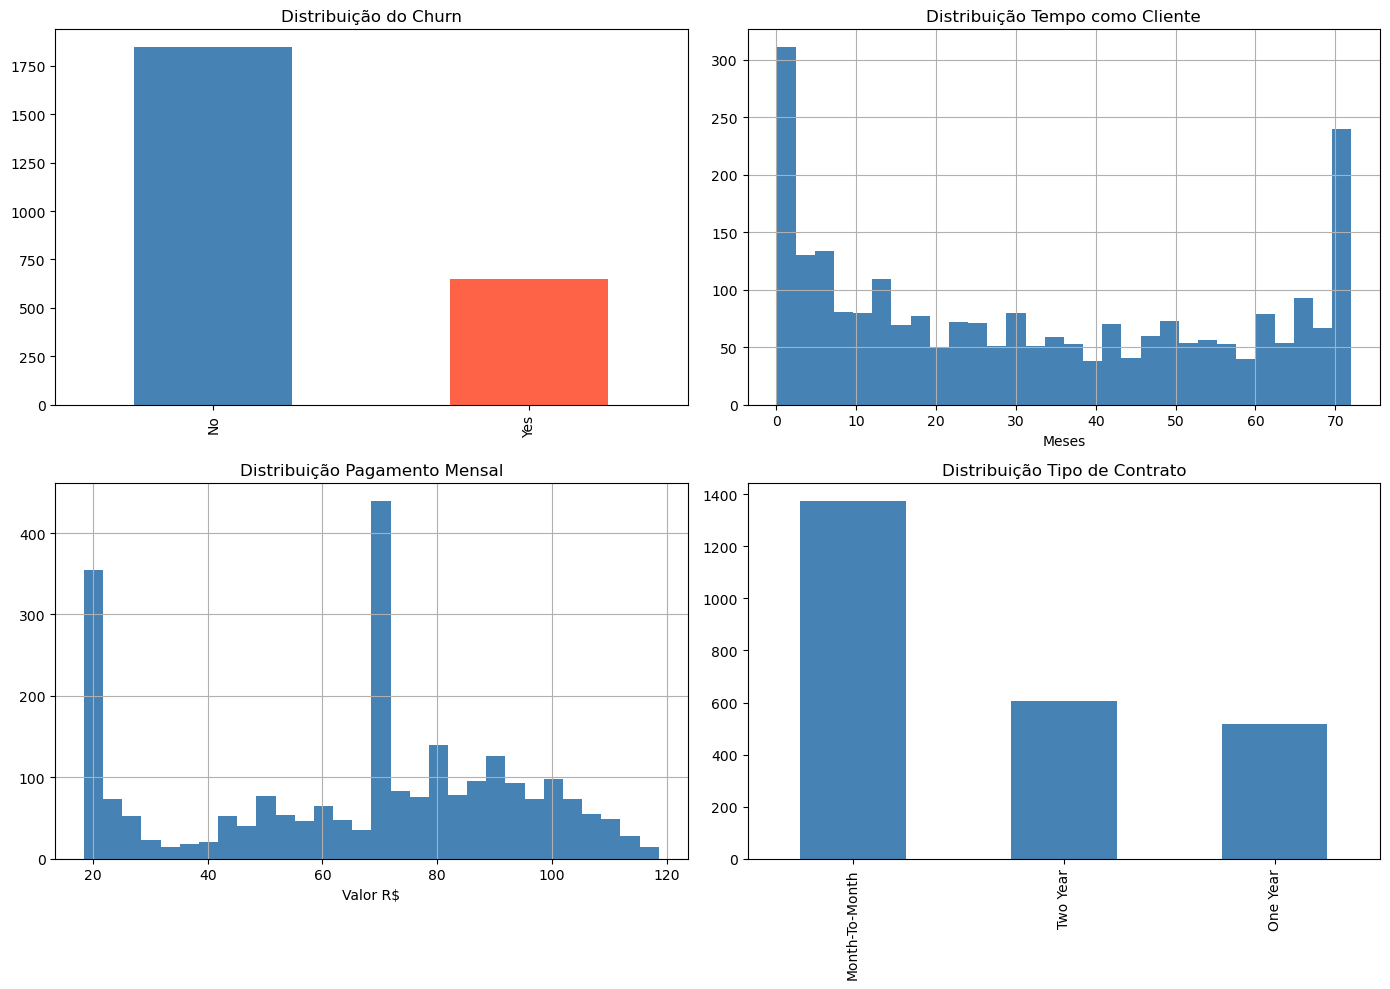

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — Distribuição do Churn
df['churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue', 'tomato'])
axes[0,0].set_title('Distribuição do Churn')
axes[0,0].set_xlabel('')

# 2 — Distribuição do Tempo como Cliente
df['tempo_cliente'].hist(bins=30, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Distribuição Tempo como Cliente')
axes[0,1].set_xlabel('Meses')

# 3 — Distribuição do Pagamento Mensal
df['pagamento_mensal'].hist(bins=30, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Distribuição Pagamento Mensal')
axes[1,0].set_xlabel('Valor R$')

# 4 — Tipo de Contrato
df['tipo_contrato'].value_counts().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Distribuição Tipo de Contrato')
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.show()

In [20]:
booleanas = ['idoso', 'casado', 'dependentes', 'churn']

for col in booleanas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


--- idoso ---
idoso
0    83.9%
1    16.1%
Name: proportion, dtype: object

--- casado ---
casado
No     50.7%
Yes    49.3%
Name: proportion, dtype: object

--- dependentes ---
dependentes
No     68.5%
Yes    31.5%
Name: proportion, dtype: object

--- churn ---
churn
No     74.0%
Yes    26.0%
Name: proportion, dtype: object


# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


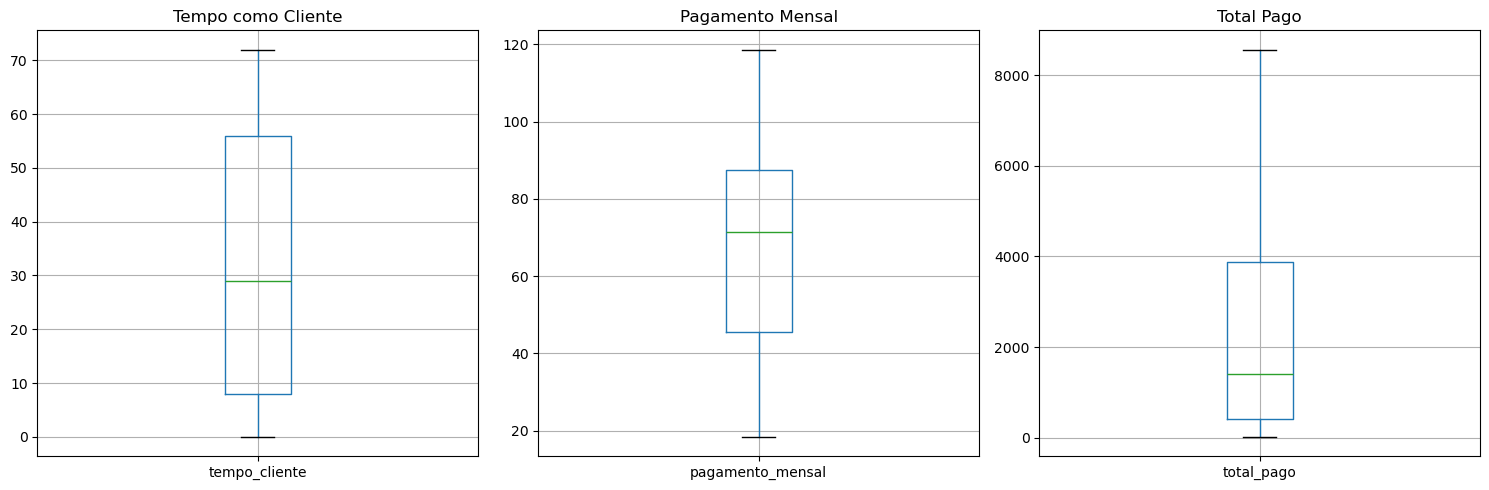

In [25]:
# Boxplot das variáveis numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column='tempo_cliente', ax=axes[0])
axes[0].set_title('Tempo como Cliente')

df.boxplot(column='pagamento_mensal', ax=axes[1])
axes[1].set_title('Pagamento Mensal')

df.boxplot(column='total_pago', ax=axes[2])
axes[2].set_title('Total Pago')

plt.tight_layout()
plt.show()

In [27]:
# Justificativa: Nenhuma das três variáveis apresenta outliers espúrios.
# Os valores extremos refletem comportamentos reais do negócio:
# - Clientes antigos naturalmente têm total_pago mais alto
# - Pagamentos altos refletem planos premium reais
# - Remover esses registros causaria perda de informação legítima
print("Nenhum outlier removido — valores extremos são explicados pelo negócio.")

Nenhum outlier removido — valores extremos são explicados pelo negócio.


# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

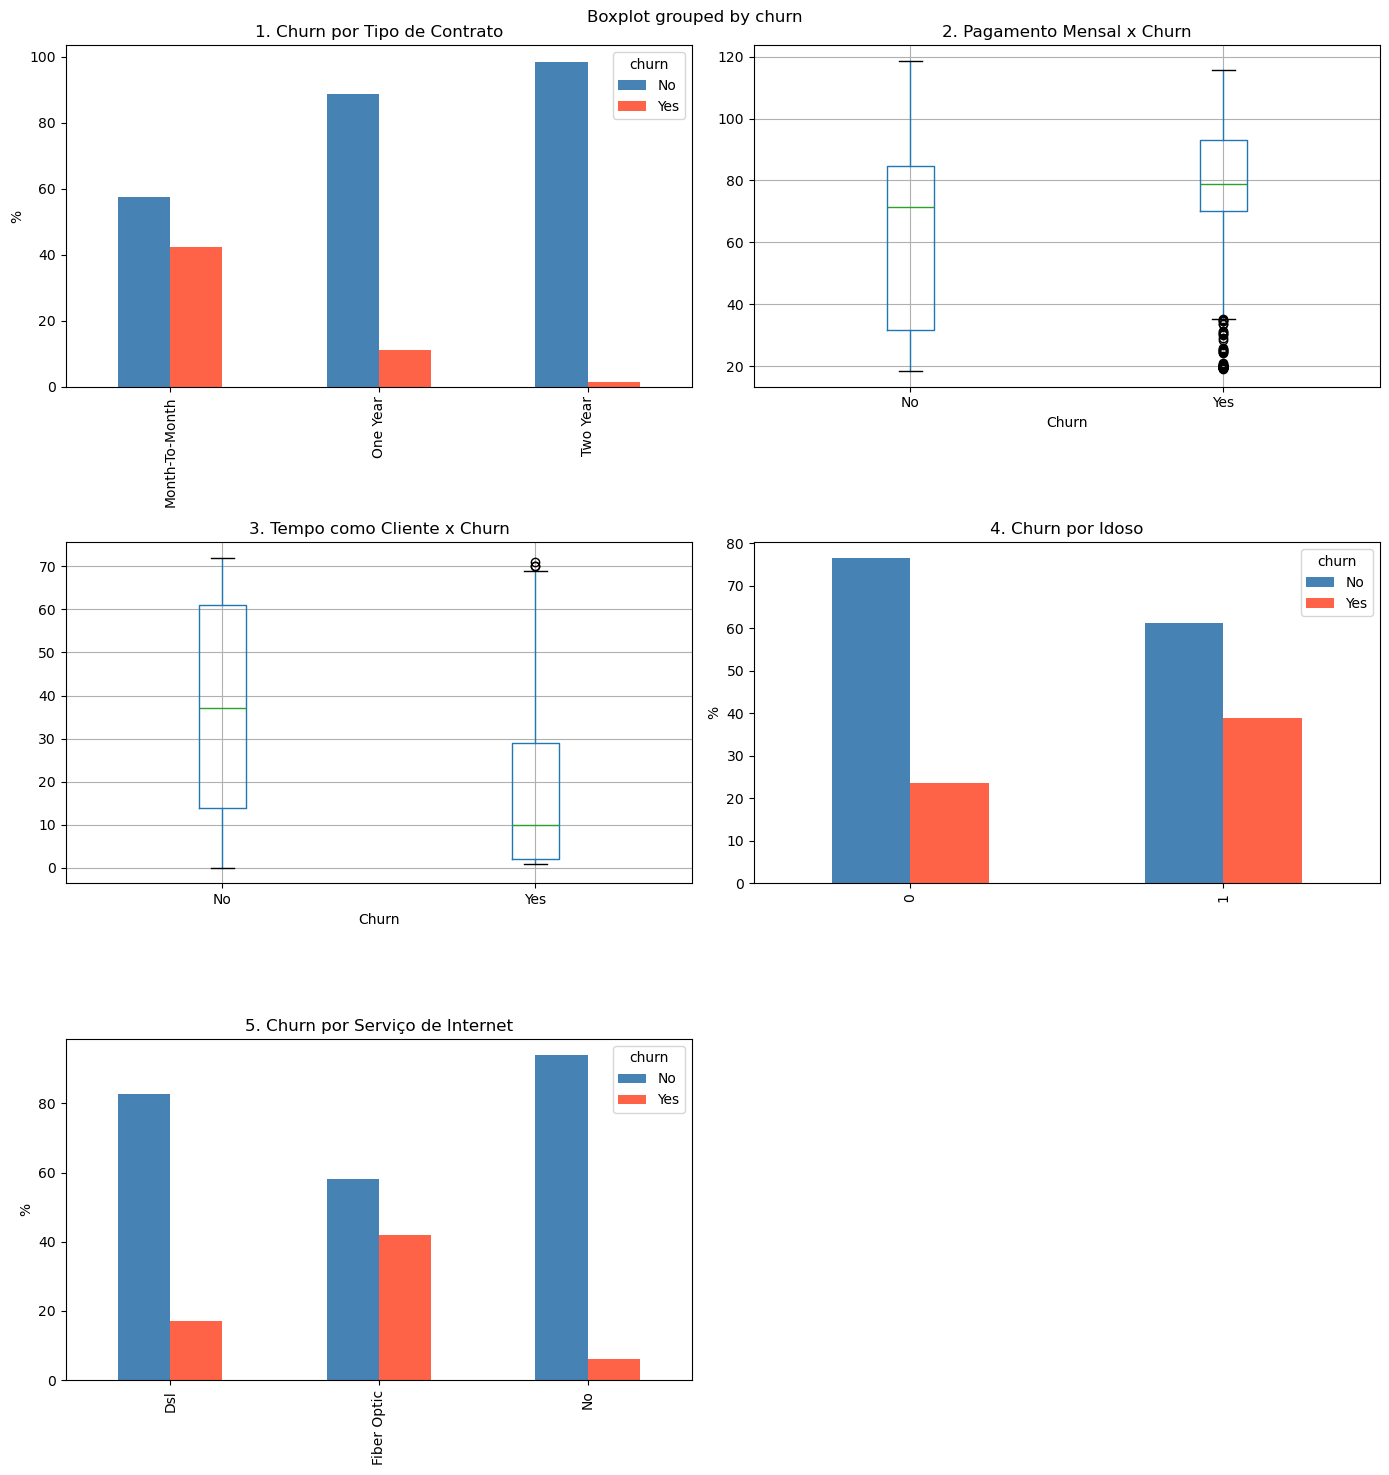

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1 — Tipo de contrato x Churn
df.groupby('tipo_contrato')['churn'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[0,0], color=['steelblue', 'tomato'])
axes[0,0].set_title('1. Churn por Tipo de Contrato')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('%')

# 2 — Pagamento Mensal x Churn
df.boxplot(column='pagamento_mensal', by='churn', ax=axes[0,1])
axes[0,1].set_title('2. Pagamento Mensal x Churn')
axes[0,1].set_xlabel('Churn')

# 3 — Tempo como Cliente x Churn
df.boxplot(column='tempo_cliente', by='churn', ax=axes[1,0])
axes[1,0].set_title('3. Tempo como Cliente x Churn')
axes[1,0].set_xlabel('Churn')

# 4 — Idoso x Churn
df.groupby('idoso')['churn'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[1,1], color=['steelblue', 'tomato'])
axes[1,1].set_title('4. Churn por Idoso')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('%')

# 5 — Serviço de Internet x Churn
df.groupby('servico_internet')['churn'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[2,0], color=['steelblue', 'tomato'])
axes[2,0].set_title('5. Churn por Serviço de Internet')
axes[2,0].set_xlabel('')
axes[2,0].set_ylabel('%')

axes[2,1].axis('off')  # célula vazia

plt.tight_layout()
plt.show()

## Análise Bivariada

### A) Insights

**1. Tipo de Contrato x Churn**
Clientes Month-to-Month têm quase 40% de churn. Contratos de 2 anos têm praticamente zero. Quanto maior o compromisso, menor o cancelamento.

**2. Pagamento Mensal x Churn**
Clientes que pagam acima de R$70-80 por mês cancelam mais. O custo influencia diretamente a decisão de saída.

**3. Tempo como Cliente x Churn**
Quem cancelou tinha em média 10 meses de casa. Quem ficou tinha 40 meses. Os primeiros meses são a janela de risco mais crítica.

**4. Idoso x Churn**
38% dos idosos cancelam contra 23% dos não-idosos. Perfil de alto risco.

**5. Serviço de Internet x Churn**
Fibra Óptica tem mais de 40% de churn. DSL tem 19%. Algo específico na Fibra está gerando insatisfação.

---

### B) Variáveis mais importantes

1. `tipo_contrato` — maior impacto no churn
2. `tempo_cliente` — primeiros 12 meses são críticos
3. `servico_internet` — Fibra Óptica concentra os cancelamentos
4. `pagamento_mensal` — custo alto aumenta chance de saída
5. `idoso` — perfil de risco elevadoo — merece atenção especial |